In [1]:
# setup and load libraries
import numpy as np
import main, cv2, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import MNIST
from inverse.orthogonal import LinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

SSIM = MetricSSIM(data_range=1.0, sigma=1.0, reduction=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Setup and Load Dataset

In [3]:
data = MNIST()
train_set = data.train_set()
test_set = data.test_set()

In [4]:
def show_image(image_set):
    n_row = 4
    n_col = 4
    fig, axs = plt.subplots(n_row, n_col, figsize=(n_col * 1, 
                            n_row * 1), sharex=True, sharey=True)

    for idx in range(n_row * n_col):
        axs.flat[idx].imshow(image_set[idx], cmap='gray')
        axs.flat[idx].axis('off')

    fig.tight_layout()

In [5]:
test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [6]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [7]:
model_path = './assets/unet_mnist.pt'
model = init_UNet({'num_blocks':2})
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

### PCA

In [8]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_
print('PCA Matrix', pcs.shape)

PCA Matrix (784, 784)


### OLM Examples

In [9]:
loss = torch.nn.MSELoss(reduction='sum')
def compute_loss(recon, test, test_torch):
    mse_val = (loss(test_torch, recon) / recon.shape[0]).item()
    recon_numpy = recon.permute([0, 2, 3, 1]).detach().cpu().numpy()
    psnr_val = psnr(test, recon_numpy)
    
    return mse_val, psnr_val

In [10]:
base_path = './olm_result/MNIST/all_digit/%d_MSE_mnist.npy'

recon_batch = 32
recon_shape = [-1, im_size[0], im_size[2], im_size[1]]

samples = [1, 2, 4, 8, 16, 32, 96]
n_repeat = 5
all_recon = [[], [], [], [], [], []]

In [11]:
for index in tqdm(range(len(samples))):
    n_sample = samples[index]
    
    # LinearInverse Object
    solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
    solver.h_init = 0.10
    solver.beta = 0.10    
    solver.run_avg = False
    
    # 1. PCA projection
    Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
    image_vec = test_torch.transpose(2, 3).flatten(1)
    recon_vec = image_vec @ Q.t() @ Q
    recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)
    recon_pca = recon_torch.detach().permute([0, 2, 3, 1]).cpu().numpy()
    
    all_recon[0].append(recon_pca)
    
    # 2. PCA + Denoiser
    solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
    
    dns_repeats = []
    for _ in range(n_repeat):
        recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
        recon_dns = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
        dns_repeats.append(recon_dns)
    all_recon[1].append(np.stack(dns_repeats))
    
    # OLM
    order = 5
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)            
    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    
    # 3. OLM Projection
    recon_vec = image_vec @ opt_mtx.t() @ opt_mtx
    recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)
    recon_olm = recon_torch.detach().permute([0, 2, 3, 1]).cpu().numpy()
    
    all_recon[2].append(recon_olm)
    
    # 4. OLM + Denoiser
    solver.assign(opt_mtx)
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
        
    olm_repeats = []
    for _ in range(n_repeat):
        recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
        recon_opt = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
        olm_repeats.append(recon_opt)
    all_recon[3].append(np.stack(olm_repeats))
    
    # 5. RND Projection
    solver.assign(torch.rand(n_sample, np.prod(im_size)).to(device))
    rnd_mtx = solver.mtx.detach()
    recon_vec = image_vec @ rnd_mtx.t() @ rnd_mtx
    recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)
    recon_rnd = recon_torch.detach().permute([0, 2, 3, 1]).cpu().numpy()
    
    all_recon[4].append(recon_rnd)
    
    # 6. RND + Denoiser
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
    
    rnd_repeats = []
    for _ in range(n_repeat):
        recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
        recon_rnd = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()
        rnd_repeats.append(recon_rnd)
    all_recon[5].append(np.stack(rnd_repeats))

100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [06:32<00:00, 56.01s/it]


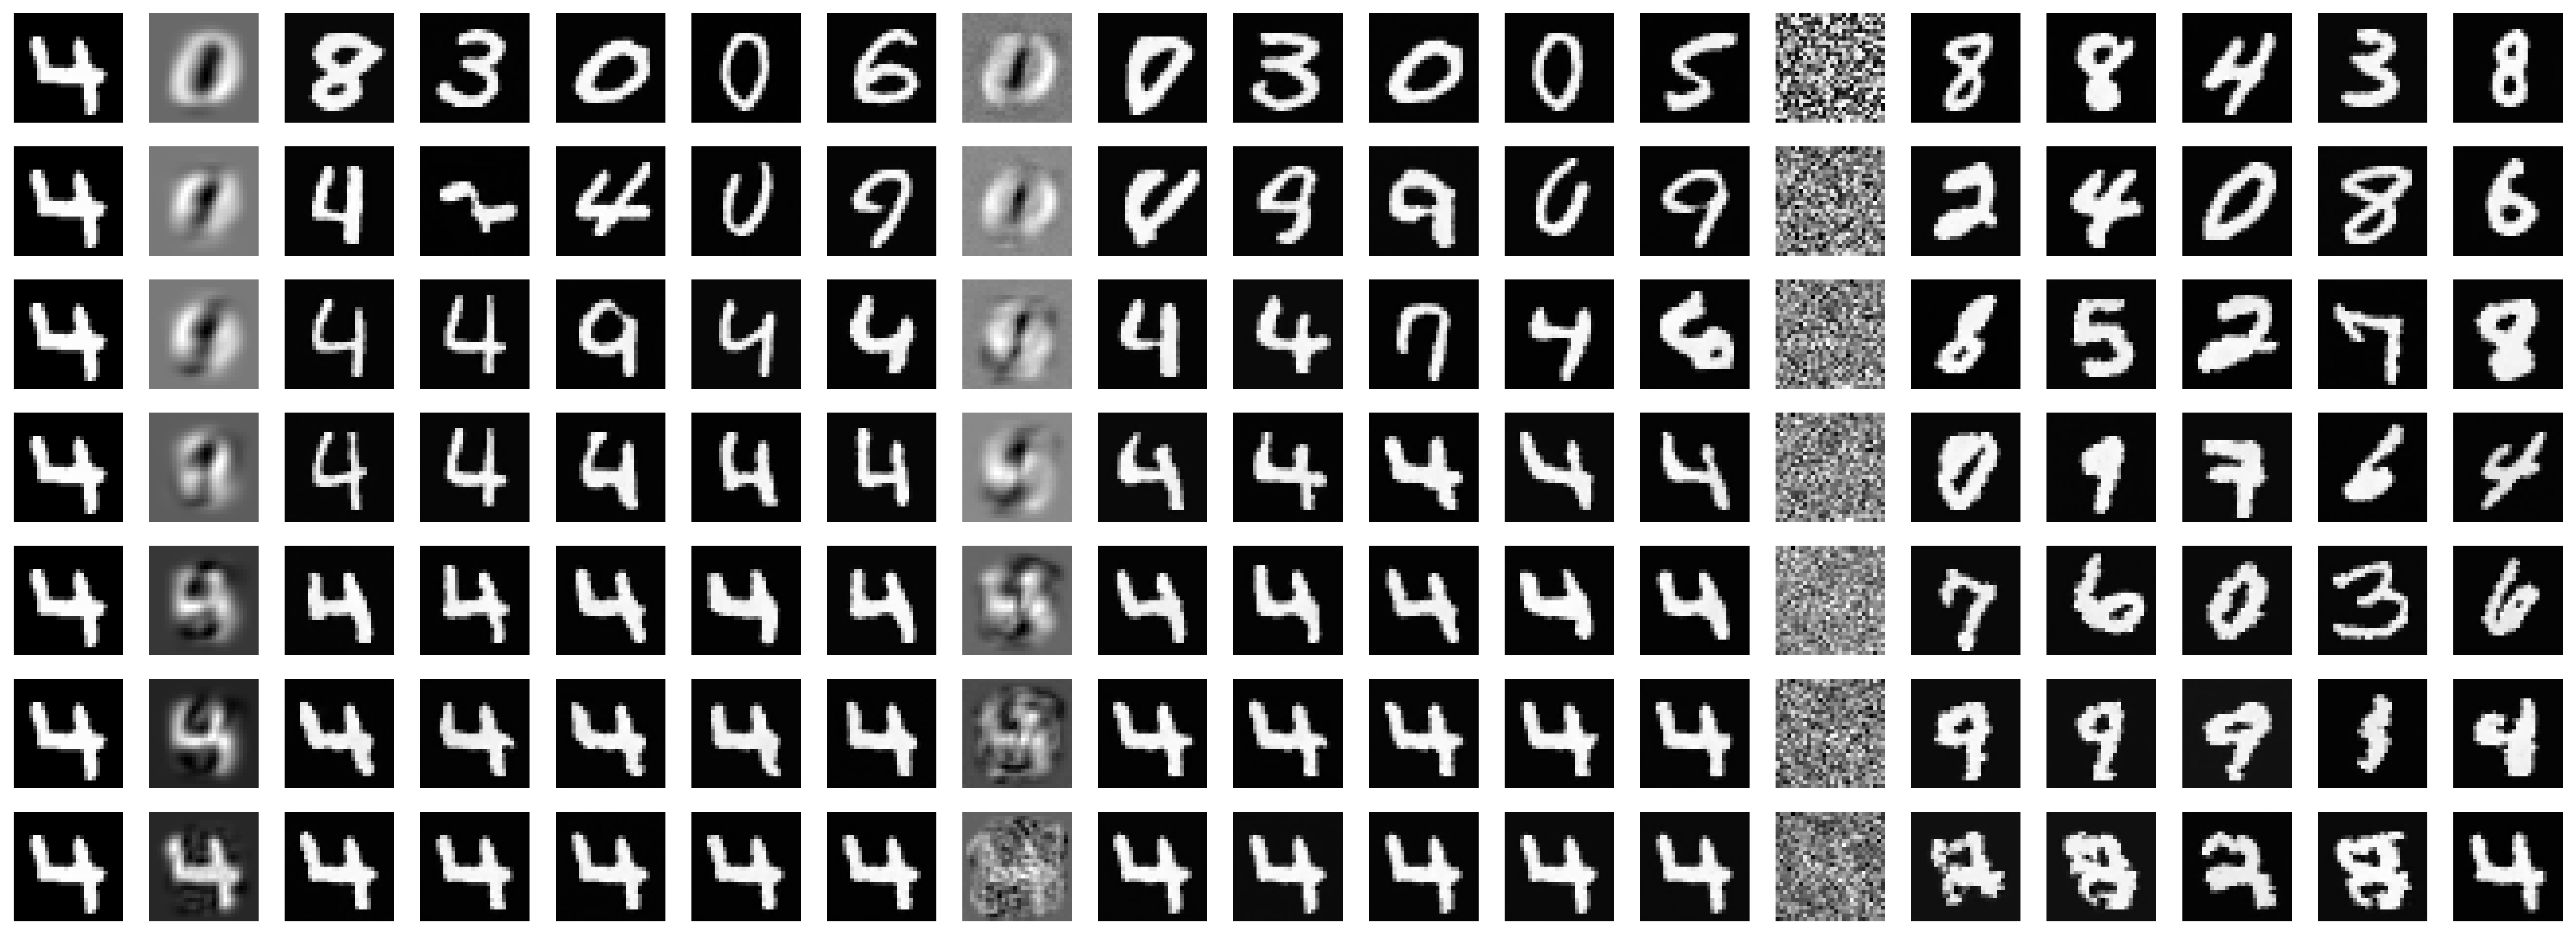

In [20]:
n_image = 1 + 1 + n_repeat + 1 + n_repeat + 1 + n_repeat
img_idx = 493

fig, axs = plt.subplots(len(samples), n_image, figsize=(n_image, len(samples)))

for idx in range(len(samples)):
    axs[idx][0].imshow(test_set[img_idx], cmap='gray')
    axs[idx][1].imshow(all_recon[0][idx][img_idx], cmap='gray')
    axs[idx][2 + n_repeat].imshow(all_recon[2][idx][img_idx], cmap='gray')
    axs[idx][2 + n_repeat + 1 + n_repeat].imshow(all_recon[4][idx][img_idx], cmap='gray')
    
    for idy in range(n_repeat):
        axs[idx][2 + idy].imshow(all_recon[1][idx][idy][img_idx], cmap='gray')
        axs[idx][2 + n_repeat + 1 + idy].imshow(all_recon[3][idx][idy][img_idx], cmap='gray')
        axs[idx][2 + n_repeat + 1 + n_repeat + 1 + idy].imshow(all_recon[5][idx][idy][img_idx], cmap='gray')
    
for ax in axs.flat:
    ax.axis('off')
    
fig.tight_layout()

In [21]:
if save_figure:
    fig_name = 'images_mnist'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')